In [14]:
#base python packages
import os
import numpy as np
import matplotlib.pyplot as mp
import pandas as pd

#geospatial packages
import geopandas as gpd
import rasterio as rio
import rasterio.plot
from shapely.geometry import Point
from rasterio.mask import mask
from shapely.ops import linemerge

#functions to make transects
from transect_extraction_functions import addpts, make_perp_transects

## Load centerline shapefiles
The files here refers to the average valley and channel centerlines adjacent to the Slumgullion landslide near Lake City, CO--replace this with your valley and/or channel centerline of interest.
* Note: for multi-temporal channel analyses, it's helpful to define an 'along-valley' coordinate system using a Valley Centerline since the Channel Centerline may change over time. Here, we will just use a single channel centerline for demonstration purposes

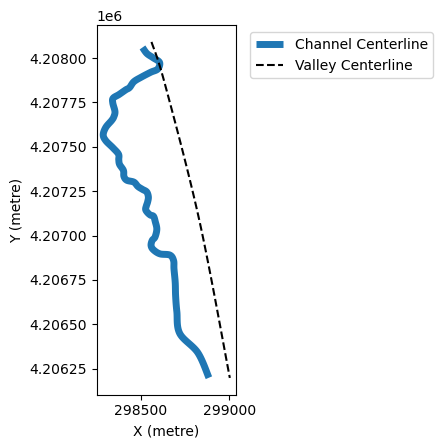

In [15]:
centerline_fn = r'data/channel_centerline.shp'
centerline_gdf = gpd.read_file(centerline_fn)
units = centerline_gdf.crs.axis_info[0].unit_name

valleyline_fn = r'data/valley_centerline.shp'
valleyline_gdf = gpd.read_file(valleyline_fn)
#plot
f, ax = mp.subplots()
centerline_gdf.geometry.plot(ax=ax, label='Channel Centerline', linewidth=5)
valleyline_gdf.geometry.plot(ax=ax, linestyle='--', color='black', label='Valley Centerline')
ax.set_xlabel('X (%s)'%units)
ax.set_ylabel('Y (%s)'%units)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

We will now extract the geometries of these to obtain Shapely.Linestring objects

* Note: if your shapefile is a combination of multiple lines, you may end up with a centerline_gdf GeoDataFrame that combines to a Shapely.MultiLineString object. You can refine this by declaring: ```centerline = linemerge(centerline_gdf.geometry.iloc[0])``` using the ```shapely.ops.linemerge``` function.

In [16]:
centerline = centerline_gdf.geometry.iloc[0]
valleyline = valleyline_gdf.geometry.iloc[0]

## Extract Channel Topography

### Load DEM
A small example DEM for the Slumgullion landslide region near Lake City, CO is included for this example.

In [17]:
proj_fn = 'data/slum_DEM_clipped.tif'

src_proj = rio.open(proj_fn)
nodataval = src_proj.nodata
src_proj.profile

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': -9999.0, 'width': 1558, 'height': 2156, 'count': 1, 'crs': CRS.from_wkt('PROJCS["NAD83 / UTM zone 13N",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-105],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","26913"]]'), 'transform': Affine(1.0244209941436833, 0.0, 297882.93636408146,
       0.0, -1.0970874025472586, 4208349.951466296), 'blockxsize': 1558, 'blockysize': 1, 'tiled': False, 'interleave': 'band'}

We create equidistant points along the valley centerline to extract topography. Here, we set this to be 5 units of the native shapefile coordinate system. Set the ```dl``` value to your desired transect spacing. You can check the units of your shapefile with ```centerline_gdf.crs.axis_info[0].unit_name```. We then sample topography at these points from the associated DEM stored as `src_proj` 

extracted elevations at 473 points along the centerline


Text(0, 0.5, 'Elevation (m)')

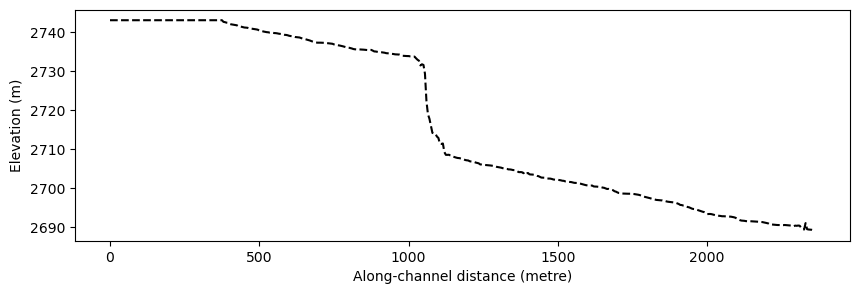

In [18]:
dl = 5
along_l_dist, xpts, ypts = addpts(centerline, dl)
pts = [(x,y) for (x,y) in zip(xpts, ypts)] #format list of points to extract elevation
#extract elevation from DEM
z = np.ravel([pt for pt in rio.sample.sample_gen(src_proj, pts)])
print('extracted elevations at %d points along the centerline'%len(xpts))

f, ax = mp.subplots(figsize=(10,3))
ax.plot(along_l_dist, z, color='k', linestyle='--')
ax.set_xlabel('Along-channel distance (%s)'%units)
ax.set_ylabel('Elevation (m)')

### Plot elevation data with channel centerline
Note: here I have plotted elevation with respect to 'y' since this channel is oriented nearly N-S. However, this may also be plotted with `along_l_dist`

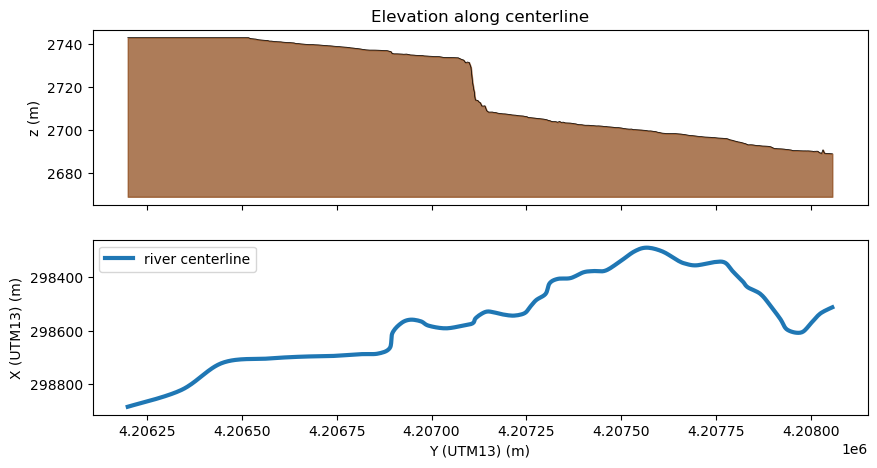

In [27]:
zmin = min(z) - 20 #define minimum elevation for plotting
f, ax = mp.subplots(nrows=2, figsize=(10,5), sharex=True)
ax[0].plot(ypts, z, color='k', linewidth=0.5)
ax[0].fill_between(ypts, zmin, z, color='saddlebrown', alpha=0.7)
ax[1].plot(ypts, xpts, linewidth=3, label='river centerline')
ax[0].set_ylabel('z (m)')
ax[1].set_xlabel('Y (UTM13) (m)')
ax[1].set_ylabel('X (UTM13) (m)')
ax[0].set_title('Elevation along centerline')
ax[1].legend()
ax[1].invert_yaxis() #invert y-axis to match DEM

## Create transects and extract cross-sections

Next, we create transects perpendicular to the valley centerline where we will sample topography. Here, the length of each transect is ```L=1000``` m, we have also set a ```DEM_res``` here as we preparing to sample the underlying DEM topography at 3m spacing across the transect.

In [20]:
L = 1000
transect_spacing = 10
along_v_dist, xpts_valley, ypts_valley = addpts(valleyline, transect_spacing)
pts = [(x,y) for (x,y) in zip(xpts_valley, ypts_valley)] #format list of points to extract elevation
valley_transects = make_perp_transects(xpts_valley, ypts_valley, L, DEM_res=3)
ntrans = len(valley_transects)
print('generated %d transects'%ntrans)

generated 193 transects


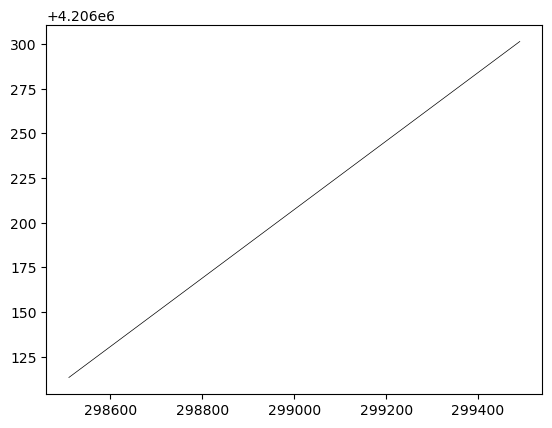

In [21]:
i=0
mp.plot(valley_transects[i]['x'],
        valley_transects[i]['y'],
        color='k',
        linewidth=0.5,) 

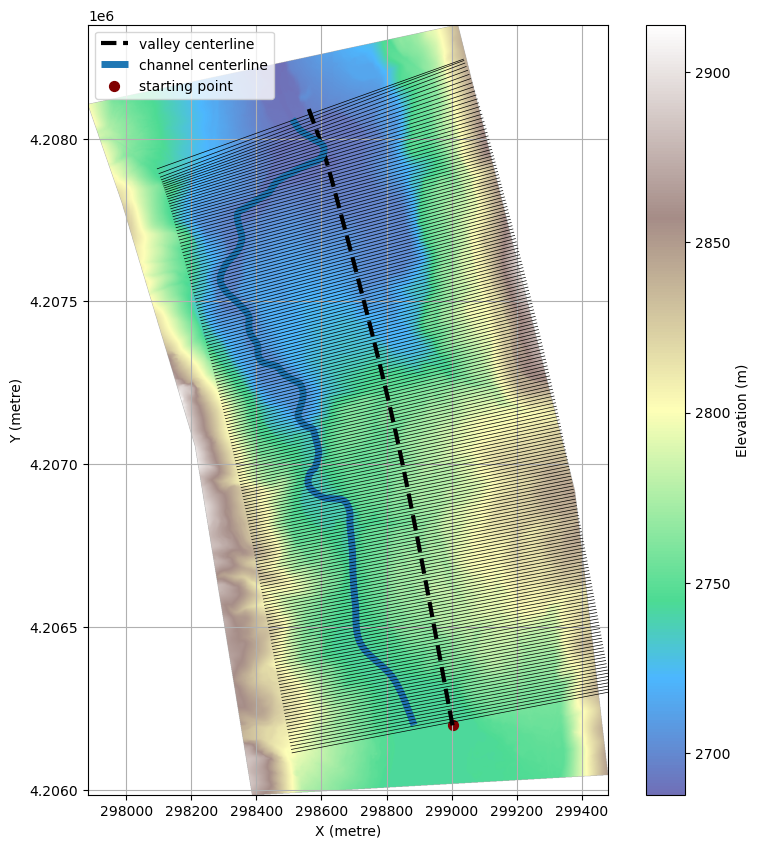

In [28]:
f, ax = mp.subplots(figsize=(10,10))
#plot centerlines
valleyline_gdf.geometry.plot(ax=ax, label='valley centerline', linewidth=3, linestyle='--', color='k')
centerline_gdf.geometry.plot(ax=ax, label='channel centerline', linewidth=5)
#plot "starting point" (should be upstream end of valley centerline)
ax.scatter(xpts_valley[0],
           ypts_valley[0],
           color='maroon', s=50, zorder=1, label='starting point')
#plot transects
for i in range(ntrans):
    ax.plot(valley_transects[i]['x'],
            valley_transects[i]['y'],
            color='k',
            linewidth=0.5,) 
#plot DEM
dem_plot = rio.plot.show(src_proj,
              cmap='terrain',
              ax=ax,
              alpha=0.7)
#add colorbar
im=dem_plot.get_images()[0]
f.colorbar(im, ax=ax, orientation='vertical', label='Elevation (m)')
ax.legend()
ax.set_xlabel('X (%s)'%units)
ax.set_ylabel('Y (%s)'%units)
ax.grid(True)

### Extract topography at transects

In [23]:
#sample DTM at transect points
z_samples = []
for i in range(len(valley_transects)):
    #sample z values using rasterio nearest neighbor
    tsect_points = [(x,y) for (x,y) in zip(valley_transects[i]['x'], valley_transects[i]['y'])]
    sampled = np.ravel([pt for pt in rio.sample.sample_gen(src_proj, tsect_points)])
    z_samples.append(sampled)

### Create a nice way of storing our transects
* We will store the extracted transect elevations in a dictionary indexed as `ti` where `i` is transect number. Each entry holds a geodataframe of:
    * `dist_along_line`: distance along each transect in DEM coordinates
    * `x_coord`: x coordinate of points along transect
    * `y_coord`: y coordinate of points along transect
    * `elev` : extracted topography along transect

In [24]:
transects_gdfs = {}
for i in range(len(valley_transects)):
    transects_gdfs['t%d'%i] = gpd.GeoDataFrame(crs = 'EPSG:32610',
                                               geometry = [Point(x, y) for x, y in zip(valley_transects[i]['x'], valley_transects[i]['y'])])
    transects_gdfs['t%d'%i]['dist_along_tsect'] = valley_transects[i]['d']
    transects_gdfs['t%d'%i]['x_coord'] = valley_transects[i]['x']
    transects_gdfs['t%d'%i]['y_coord'] = valley_transects[i]['y']
    transects_gdfs['t%d'%i]['elev'] = z_samples[i]

### Example transect plot
We can now plot these transects in various ways. The below example shows a plot of stacked transects plotted along a 'dummy' y axis and colored by local topography slope. Areas that may be susceptible to flooding at 1m above the water surface are also plotted.

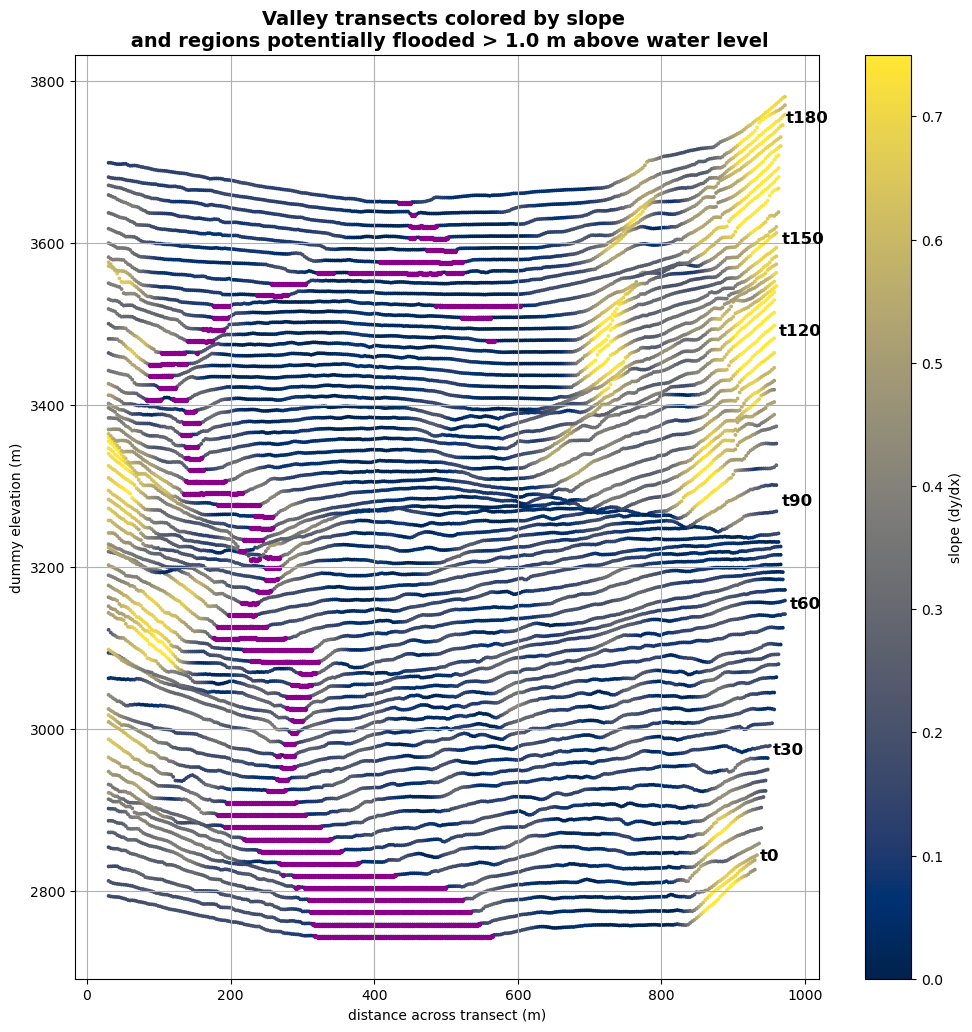

In [25]:
# define a function to calculate slope from elevation data
def np_slope(data):
    return np.polyfit(data.index, data.values, deg=1)[0]

f, ax = mp.subplots(figsize=(12,12))
dummy_z = 0 #dummy z value to offset transects for plotting
n_smooth = 20 #number of points to smooth slope calculation
water_buffer = 1 #buffer above water level to highlight potential flooding
for i in range(len(valley_transects)):
    if i % 3 == 0:
        #define filters for each transect
        no_data_filter = transects_gdfs['t%d'%i]['elev'] > nodataval #no data
        water_level = transects_gdfs['t%d'%i]['elev'][no_data_filter].min() #find water level
        flood_filter = transects_gdfs['t%d'%i]['elev'] < (water_level + water_buffer) #define flooded points
        #plot transect points colored by slope
        im=ax.scatter(transects_gdfs['t%d'%i]['dist_along_tsect'][no_data_filter],
                      transects_gdfs['t%d'%i]['elev'][no_data_filter] + dummy_z,
                      c = abs(transects_gdfs['t%d'%i][no_data_filter].set_index('dist_along_tsect')['elev'].rolling(n_smooth, center=True).apply(np_slope, raw=False)),
                      cmap = 'cividis',
                      s=3,
                      label='transect %d'%i,
                      vmin=0,
                      vmax=0.75,
                      linewidth=1)
        #plot flooded points
        ax.scatter(transects_gdfs['t%d'%i]['dist_along_tsect'][no_data_filter][flood_filter],
                    transects_gdfs['t%d'%i]['elev'][no_data_filter][flood_filter] + dummy_z,
                    color='darkmagenta',
                    s=8,
                    linewidth=1)

        if i % 10 == 0:
            ax.text(transects_gdfs['t%d'%i]['dist_along_tsect'][no_data_filter].iloc[-1]-20,
                    transects_gdfs['t%d'%i]['elev'][no_data_filter].iloc[-1] + dummy_z + 2,
                    't%d'%i, fontsize=12, fontweight='bold')
            
        dummy_z +=15

ax.grid(zorder=0)
ax.set_xlabel('distance across transect (m)')
ax.set_ylabel('dummy elevation (m)')
ax.set_title('Valley transects colored by slope \n and regions potentially flooded > %.1f m above water level'%water_buffer, fontweight='bold', fontsize=14)
mp.colorbar(im).set_label('slope (dy/dx)')

## Export Data
Uncomment if you wish to save your channel profile and transect data in .csv format
* can be loaded into other GIS applications

In [26]:
# long_profile = pd.DataFrame(
#     {'d': along_l_dist,
#      'x': xpts,
#      'y': ypts,
#      'elev': z}
# )
# long_profile.to_csv('long_profile.csv', index=False)

# tabular_transects = pd.DataFrame()
# for i in range(len(valley_transects)):
#     tsect_i = transects_gdfs['t%d'%i]
#     tsect_i['id'] = np.ones(len(tsect_i), dtype=int) * i
#     tabular_transects = pd.concat([
#         tabular_transects,
#         tsect_i[['id','x_coord','y_coord','elev']]],
#         ignore_index=True
#         )
# tabular_transects.to_csv('transects.csv', index=False)